<ipython-input-2-765f60568188>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000 * np.exp(-t)
<ipython-input-2-765f60568188>:17: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


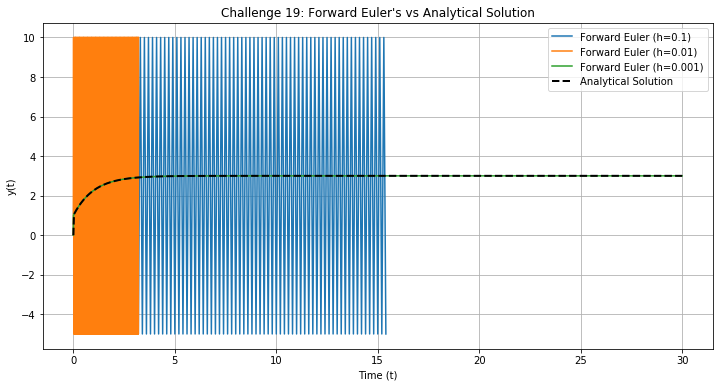

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000 * np.exp(-t)


def analytical_solution(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        
    return t_values, y_values

y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001]

plt.figure(figsize=(12, 6))

for h in h_values:
    t_fe, y_fe = forward_euler(f, y0, t0, tf, h)
    y_fe_clipped = np.clip(y_fe, -5, 10) 
    plt.plot(t_fe, y_fe_clipped, label=f'Forward Euler (h={h})')

t_exact = np.linspace(t0, tf, 1000)
plt.plot(t_exact, analytical_solution(t_exact), 'k--', label='Analytical Solution', linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title("Challenge 19: Forward Euler's vs Analytical Solution")
plt.legend()
plt.grid(True)
plt.show()